# Task 3: Individual-genome evaluation of selected CRISPR guides

## Study questions

1. Are any selected guides absent or unusable in any of the seven genomes?
2. Does predicted off-target risk differ among the seven genomes?

This notebook retains the validated analysis used in the previous scientific report and updates only the selected Task 2 guide pools.

On-target availability is assessed by reconstructing both alleles at each guide target. Off-target variation is assessed at the corresponding candidate sites in the two CRISPOR off-target workbooks. Missing VCF coverage and unresolved observations are reported rather than classified as unchanged.

Methods overview
- Import the eight selected Task 2 guides dynamically.
- Map each complete 23-base target to GRCh38 in both orientations and validate its PAM.
- Reconstruct both on-target alleles for seven individuals and classify guide availability using a modular `VariantAnalyzer`.
- Parse the detailed CRISPOR off-target workbooks and validate each candidate against GRCh38.
- Reconstruct every reference-valid off-target with compatible VCF coverage.
- Compare personalised and reference PAM state and protospacer mismatch count.
- Report increased-risk cases, exclusions, unresolved cases, and direct answers.

The analysis assumes the project files and regional chromosome VCFs have already been prepared. Missing evidence is never interpreted as a reference allele or as unchanged risk.

In [1]:
import sys
sys.path.append("..")
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd

from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown

# Import the refactored heavy-lifting variant logic
from utils.variant_utils import VariantAnalyzer, orient_sequence, canonical_chromosome, plot_gene_grna_architecture, plot_all_chromosome_targets

DATA_DIR = Path('../data')
RESULTS_DIR = Path('../results')
TABLE_DIR = RESULTS_DIR / 'tables'
FIGURE_DIR = RESULTS_DIR / 'figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_FASTA = DATA_DIR / 'GRCh38.fa'
OFFTARGET_XLS = {
    'SERPINB2': DATA_DIR / 'offtargets_hg38-chr18-63887679-63887795.xls',
    'CXCL11': DATA_DIR / 'offtargets_hg38-chr4-76035901-76036222.xls',
}
ON_TARGET_VCFS = {
    'SERPINB2': DATA_DIR / 'vcfs' / 'sampled_chr18.norm.vcf.gz',
    'CXCL11': DATA_DIR / 'vcfs' / 'sampled_chr4.norm.vcf.gz',
}
GENE_REGIONS = {
    'SERPINB2': {'chrom':'18', 'start':63871692, 'end':63903888, 'mode':'CRISPRa'},
    'CXCL11': {'chrom':'4', 'start':76033682, 'end':76041415, 'mode':'CRISPRi'},
}

# Initialize VariantAnalyzer
analyzer = VariantAnalyzer(REFERENCE_FASTA)
analyzer.add_vcf('4', ON_TARGET_VCFS['CXCL11'])
analyzer.add_vcf('18', ON_TARGET_VCFS['SERPINB2'])

SAMPLES = list(analyzer.vcfs['4'].header.samples)

## Reference validation of selected guides

In [2]:
# Dynamically load the final guide pools from Task 2
cxcl11_df = pd.read_csv(TABLE_DIR / 'task2_cxcl11_crispri_final_pool.csv')
cxcl11_df['gene'] = 'CXCL11'
cxcl11_df['mode'] = 'CRISPRi'

serpinb2_df = pd.read_csv(TABLE_DIR / 'task2_serpinb2_crispra_final_pool.csv')
serpinb2_df['gene'] = 'SERPINB2'
serpinb2_df['mode'] = 'CRISPRa'

guides = pd.concat([cxcl11_df, serpinb2_df], ignore_index=True)
guides = guides.rename(columns={
    '#guideId': 'guide_id',
    'mapped_orientation': 'crispor_strand',
    'Composite_Score': 'task2_composite'
})

# Retain only the columns expected by the downstream code
guides = guides[['gene', 'mode', 'guide_id', 'targetSeq', 'crispor_strand', 'task2_composite']]
guides['targetSeq'] = guides['targetSeq'].astype(str).str.upper().str.replace(r'[^ACGTN]', '', regex=True)

if not guides['targetSeq'].str.len().eq(23).all():
    raise ValueError('Every selected targetSeq must contain 23 bases.')
if guides[['gene', 'guide_id']].duplicated().any():
    raise ValueError('Duplicate gene-guide identifiers were found.')

def map_guide(row):
    region = GENE_REGIONS[row['gene']]
    chrom = region['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(canonical_chromosome(chrom), chrom)
    region_sequence = analyzer.reference.fetch(fasta_chrom, region['start'] - 1, region['end']).upper()
    matches = []
    for strand, query in {'+':row['targetSeq'], '-':orient_sequence(row['targetSeq'], '-')}.items():
        for match in re.finditer(f'(?={re.escape(query)})', region_sequence):
            start = region['start'] + match.start()
            matches.append((start, start + 22, strand))
    if len(matches) != 1:
        return pd.Series({'fasta_chrom':chrom,'guide_start':pd.NA,'guide_end':pd.NA,'genomic_strand':pd.NA,'mapping_status':'NOT_FOUND' if not matches else 'AMBIGUOUS'})
    start, end, strand = matches[0]
    genomic = analyzer.reference.fetch(fasta_chrom, start - 1, end).upper()
    oriented = orient_sequence(genomic, strand)
    status = 'VALIDATED' if oriented == row['targetSeq'] and oriented[-3:].endswith('GG') else 'REFERENCE_OR_PAM_MISMATCH'
    return pd.Series({'fasta_chrom':chrom,'guide_start':start,'guide_end':end,'genomic_strand':strand,'mapping_status':status})

mapping = guides.apply(map_guide, axis=1)
for column in mapping.columns:
    guides[column] = mapping[column].values
if not guides['mapping_status'].eq('VALIDATED').all():
    display(guides.loc[guides['mapping_status'] != 'VALIDATED'])
    raise RuntimeError('At least one selected guide failed reference validation.')

guides.to_csv(TABLE_DIR / 'task3_guide_manifest.tsv', sep='	', index=False)
display(guides[['gene','guide_id','targetSeq','crispor_strand','genomic_strand','guide_start','guide_end','mapping_status']])

,gene,guide_id,targetSeq,crispor_strand,genomic_strand,guide_start,guide_end,mapping_status
0,CXCL11,76forw,GAAAGGTGCATGACTCAAAGAGG,reverse,-,76036145,76036167,VALIDATED
1,CXCL11,264forw,GAAGGGCATGGCTATAGCCTTGG,reverse,-,76035957,76035979,VALIDATED
2,CXCL11,261rev,AGCACACAATATCACAGCCAAGG,forward,+,76035940,76035962,VALIDATED
3,CXCL11,295forw,TTGTGTGCTACAGTTGTTCAAGG,reverse,-,76035926,76035948,VALIDATED
4,SERPINB2,40forw,TGAACTGTAACAACTCTCAGAGG,forward,+,63887699,63887721,VALIDATED
5,SERPINB2,90forw,AGAATAACCAGAGAACAACCAGG,forward,+,63887749,63887771,VALIDATED
6,SERPINB2,50rev,TCTCTGAGTTGCTGTCTGACGGG,reverse,-,63887729,63887751,VALIDATED
7,SERPINB2,77rev,TGAAATACCTGGTTGTTCTCTGG,reverse,-,63887756,63887778,VALIDATED


**Observations:**

- All 8 selected guides mapped uniquely and reproduced their expected 23-base GRCh38 target with a compatible NGG PAM. 
- The inferred genomic orientation differed from the CRISPOR display label for 8 guide(s): 
    - CXCL11 76forw, CXCL11 264forw, CXCL11 261rev, CXCL11 295forw, 
    - SERPINB2 40forw, SERPINB2 90forw, SERPINB2 50rev, SERPINB2 77rev. 
- The inferred genomic strand was used for all allele reconstruction, preventing strand-related PAM errors.

### Visualisation of Gene Architecture, First Exon, and Selected gRNA / PAM Binding Sites

To inspect the genomic context of the selected CRISPR guides across each chromosome, the following figures illustrate:
- **Full Gene Architecture (Panel A):** Complete gene locus on its respective chromosome (CXCL11 on Chr 4, SERPINB2 on Chr 18), all exons, introns with transcription orientation arrows, and prominently highlights the first exon targeted for CRISPR modulation.
- **Target Locus Architecture & gRNA / PAM Binding (Panel B):** Zooms into the first exon window, displaying the exact first exon boundaries, and visualising each selected 20nt protospacer, its corresponding 3nt PAM region, strand orientation, and predicted SpCas9 cleavage site (cut marker) with dedicated tracks ensuring zero overlap.

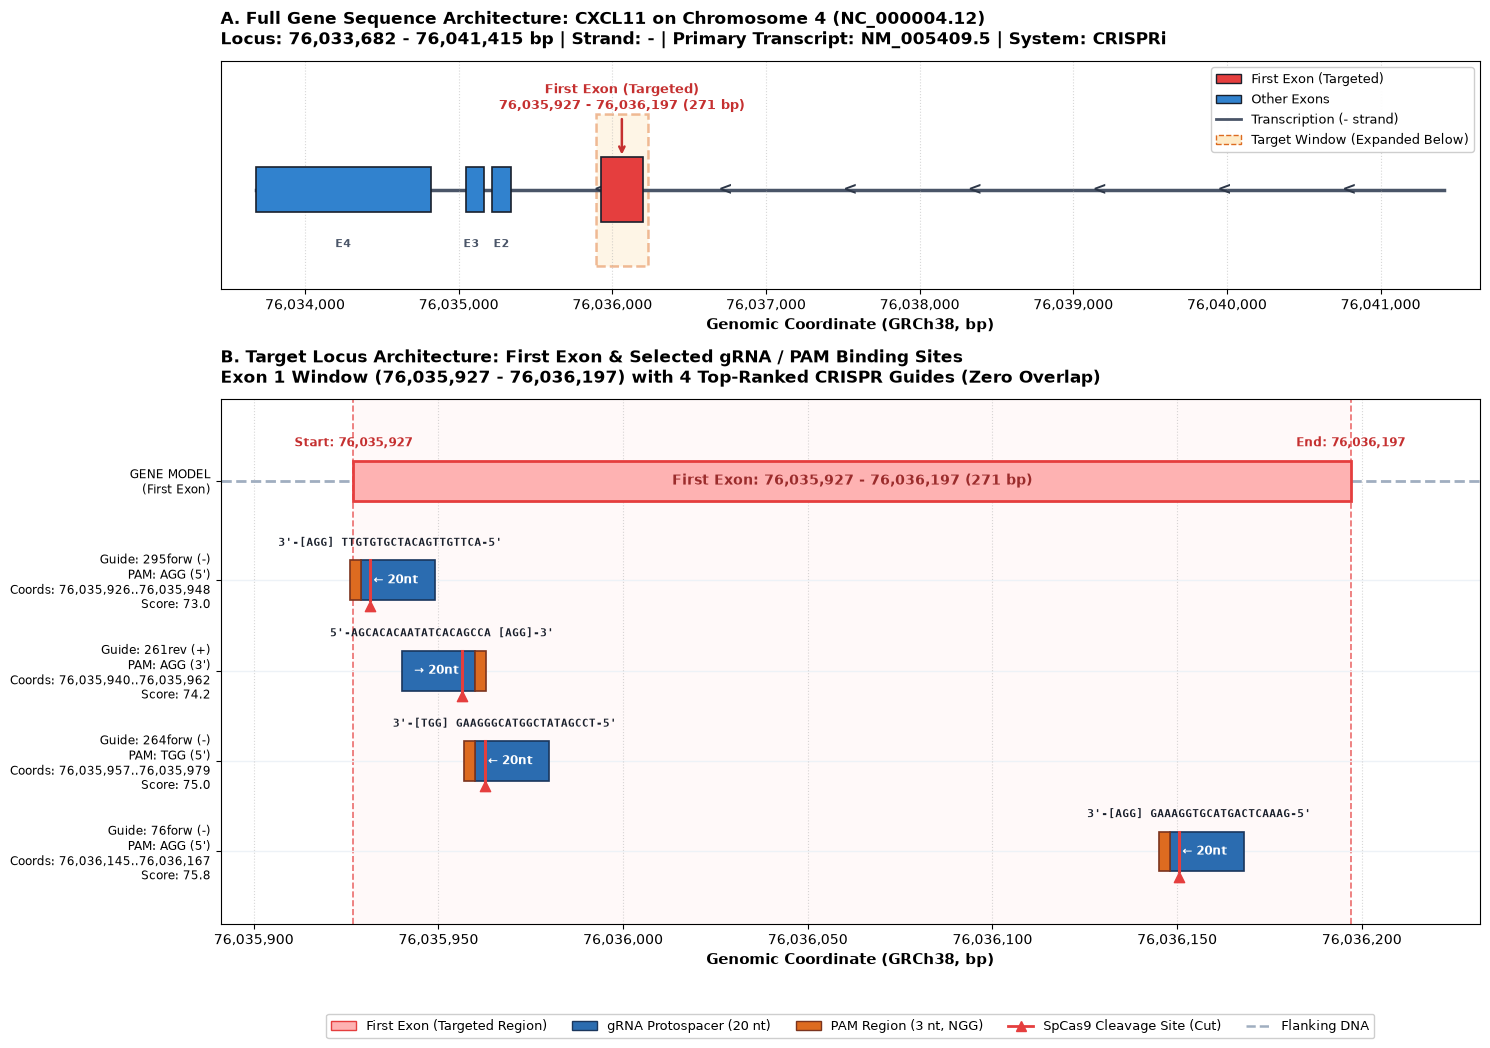

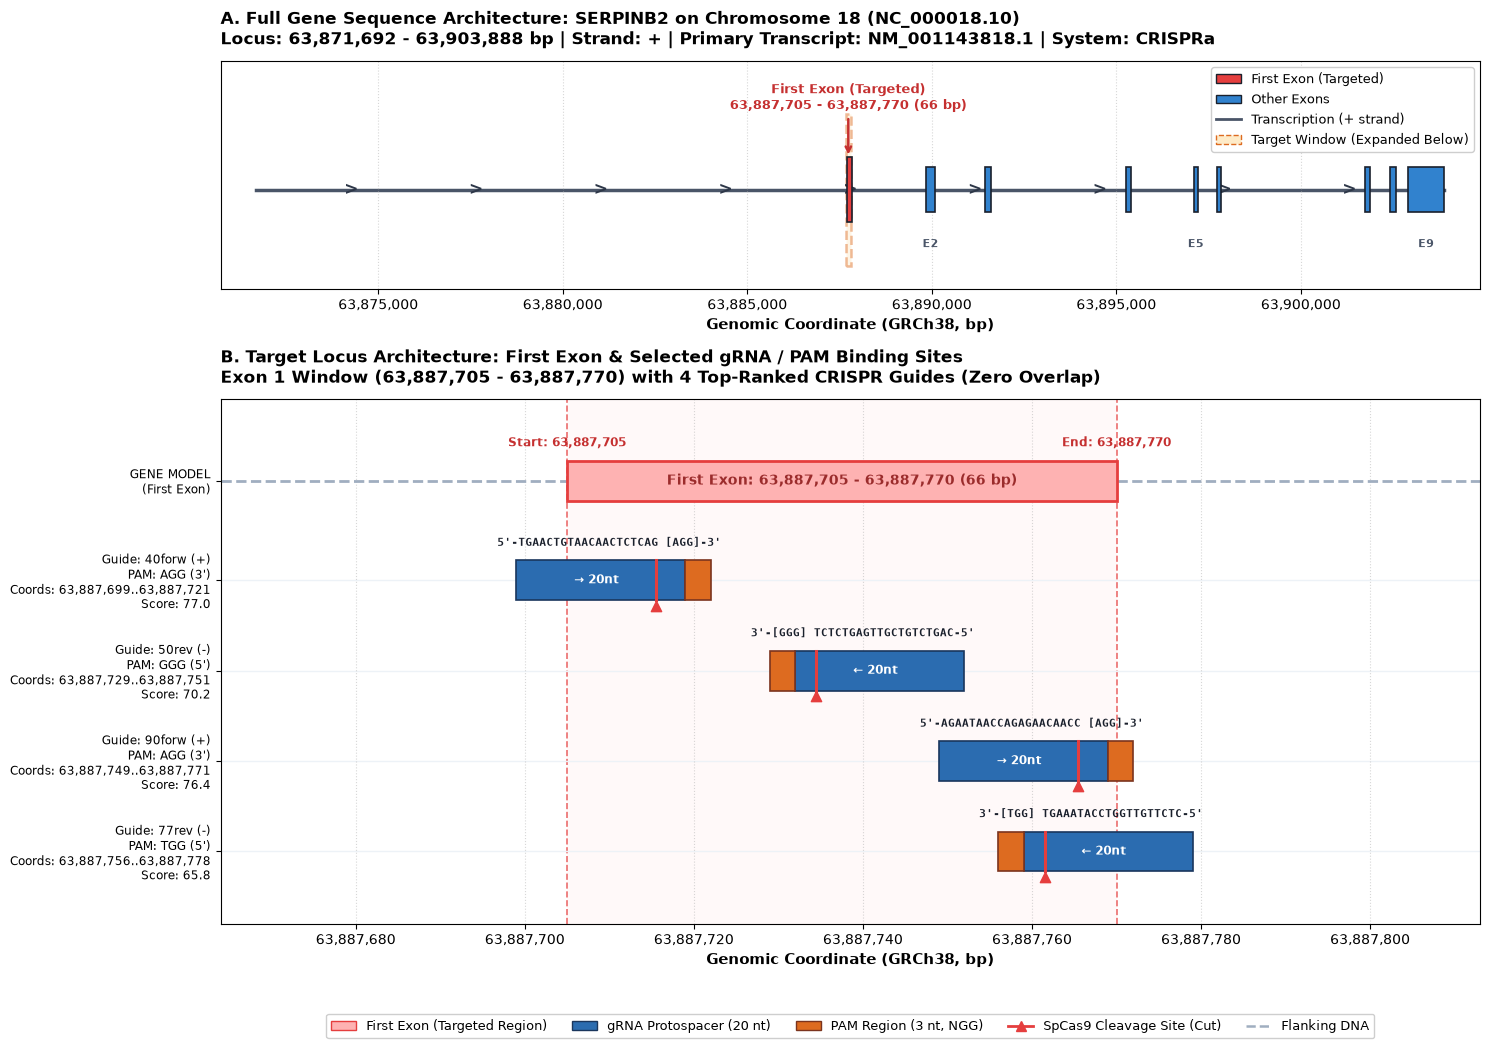

In [3]:
# Visualise gene sequence, first exon, and selected gRNA/PAM binding sites for each chromosome
for chrom, gene in [('4', 'CXCL11'), ('18', 'SERPINB2')]:
    plot_gene_grna_architecture(
        gene_or_chrom=gene,
        guides_df=guides,
        output_path=FIGURE_DIR / f'task3_{gene.lower()}_grna_architecture.png',
        show=True
    )

## On-target availability across seven genomes

In [4]:
rows = []
for _, guide in guides.iterrows():
    start, end = int(guide['guide_start']), int(guide['guide_end'])
    for sample_id in SAMPLES:
        allele_1, allele_2, reconstruction = analyzer.reconstruct_alleles(guide['fasta_chrom'], start, end, sample_id)
        for haplotype, allele in enumerate([allele_1, allele_2], 1):
            personalised = orient_sequence(allele, guide['genomic_strand'])
            rows.append({
                'sample_id':sample_id,'gene':guide['gene'],'mode':guide['mode'],'guide_id':guide['guide_id'],
                'haplotype':haplotype,'reconstruction_status':reconstruction,'personalised_23mer':personalised,
                'target_status':analyzer.classify_on_target(guide['targetSeq'], personalised),
            })

personalised_targets = pd.DataFrame(rows)
personalised_targets.to_csv(TABLE_DIR / 'task3_personalised_targets_targets.tsv', sep='	', index=False)

summary=[]
for keys, group in personalised_targets.groupby(['sample_id','gene','mode','guide_id'], sort=False):
    status = group.sort_values('haplotype')['target_status'].tolist()
    targetable = sum(value in {'UNCHANGED','DISTAL_MISMATCH'} for value in status)
    unresolved = not group['reconstruction_status'].isin(['REFERENCE_HOMOZYGOUS','RECONSTRUCTED','REFERENCE_ASSUMED']).all()
    guide_status = 'CAUTION' if unresolved or targetable == 1 or 'SEED_MISMATCH' in status else ('PASS' if targetable == 2 else 'FAIL')
    summary.append({'sample_id':keys[0],'gene':keys[1],'mode':keys[2],'guide_id':keys[3],
                    'allele_1_status':status[0],'allele_2_status':status[1],
                    'targetable_alleles':targetable,'guide_status':guide_status})

guide_sample_summary = pd.DataFrame(summary)
guide_sample_summary.to_csv(TABLE_DIR / 'task3_guide_sample_summary.tsv', sep='	', index=False)
question1_summary = guide_sample_summary.groupby(['gene','guide_id'],as_index=False).agg(
    individuals_pass=('guide_status',lambda x:int((x=='PASS').sum())),
    individuals_caution=('guide_status',lambda x:int((x=='CAUTION').sum())),
    individuals_fail=('guide_status',lambda x:int((x=='FAIL').sum())),
    minimum_targetable_alleles=('targetable_alleles','min'),
)
question1_summary['answer'] = np.where(question1_summary['individuals_fail'].eq(0),'RETAINED_IN_ALL_SEVEN','LOST_OR_UNUSABLE_IN_AT_LEAST_ONE')
question1_summary.to_csv(TABLE_DIR / 'task3_question1_summary.tsv',sep='	',index=False)
display(question1_summary)

,gene,guide_id,individuals_pass,individuals_caution,individuals_fail,minimum_targetable_alleles,answer
0,CXCL11,261rev,7,0,0,2,RETAINED_IN_ALL_SEVEN
1,CXCL11,264forw,7,0,0,2,RETAINED_IN_ALL_SEVEN
2,CXCL11,295forw,7,0,0,2,RETAINED_IN_ALL_SEVEN
3,CXCL11,76forw,7,0,0,2,RETAINED_IN_ALL_SEVEN
4,SERPINB2,40forw,7,0,0,2,RETAINED_IN_ALL_SEVEN
5,SERPINB2,50rev,7,0,0,2,RETAINED_IN_ALL_SEVEN
6,SERPINB2,77rev,7,0,0,2,RETAINED_IN_ALL_SEVEN
7,SERPINB2,90forw,7,0,0,2,RETAINED_IN_ALL_SEVEN


**Observations:**

- None of the eight selected guides was lost or rendered unusable in the seven genomes. Every guide passed in all seven individuals and retained two targetable alleles. 
- The retained guides were: CXCL11 261rev, CXCL11 264forw, CXCL11 295forw, CXCL11 76forw, SERPINB2 40forw, SERPINB2 50rev, SERPINB2 77rev, SERPINB2 90forw. 
- Consequently, both four-guide pools maintained full on-target coverage across the analysed individuals.

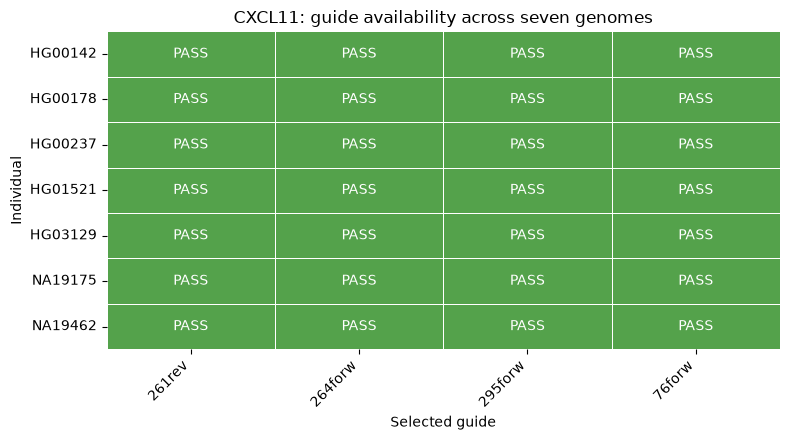

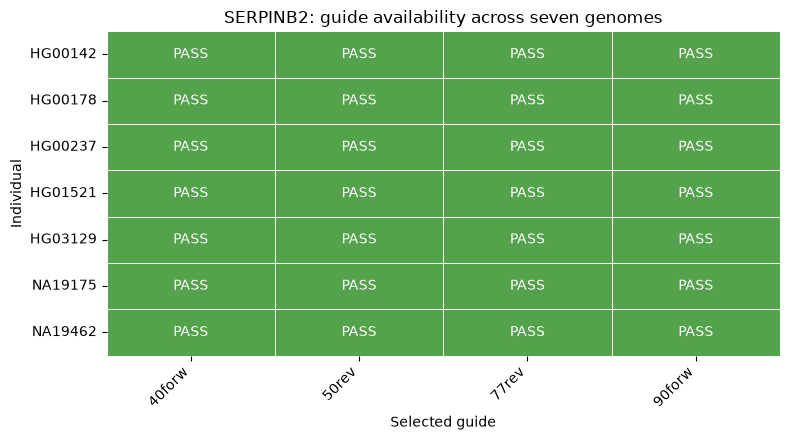

In [5]:
status_scores={'FAIL':0,'CAUTION':1,'PASS':2}
for gene in guides['gene'].unique():
    labels=guide_sample_summary.query('gene == @gene').pivot(index='sample_id',columns='guide_id',values='guide_status')
    scores=labels.apply(lambda column:column.map(status_scores)).astype(float)
    plt.figure(figsize=(8,4.5))
    sns.heatmap(scores,cmap=ListedColormap(['#E45756','#F2CF5B','#54A24B']),vmin=-0.5,vmax=2.5,
                annot=labels.to_numpy(),fmt='',linewidths=.5,linecolor='white',cbar=False)
    plt.title(f'{gene}: guide availability across seven genomes')
    plt.xlabel('Selected guide');plt.ylabel('Individual');plt.xticks(rotation=45,ha='right');plt.tight_layout()
    plt.savefig(FIGURE_DIR / f'task3_{gene.lower()}_on_target_heatmap.png',dpi=200,bbox_inches='tight')
    plt.show()

## CRISPOR candidate-site validation

In [6]:
def read_crispor_xls(path, gene):
    sheet = xlrd.open_workbook(str(path)).sheet_by_index(0)
    header = next((i for i in range(sheet.nrows) if str(sheet.cell_value(i,0)).strip() == 'guideId'), None)
    if header is None: raise ValueError(f'guideId header not found in {path.name}')
    names=[str(x).strip() for x in sheet.row_values(header)]
    records=[dict(zip(names,sheet.row_values(i))) for i in range(header+1,sheet.nrows) if str(sheet.cell_value(i,0)).strip()]
    return pd.DataFrame(records).rename(columns={
        'guideId':'guide_id','guideSeq':'guide_sequence','offtargetSeq':'offtarget_sequence',
        'mismatchCount':'reference_mismatch_count_crispor','mitOfftargetScore':'reference_mit_score',
        'cfdOfftargetScore':'reference_cfd_score','locusDesc':'locus_description'
    }).assign(gene=gene,source_file=path.name)

all_offtargets = pd.concat([read_crispor_xls(path,gene) for gene,path in OFFTARGET_XLS.items()],ignore_index=True)
for column in ['guide_id','guide_sequence','offtarget_sequence','chrom','locus_description']:
    all_offtargets[column]=all_offtargets[column].astype(str).str.strip()
all_offtargets['strand_raw']=all_offtargets['strand'].astype(str).str.strip()
all_offtargets['strand']=all_offtargets['strand_raw'].str.extract(r'^([+-])',expand=False)
all_offtargets['chrom'] = all_offtargets['chrom'].map(canonical_chromosome)
all_offtargets['start_raw']=pd.to_numeric(all_offtargets['start'],errors='raise').astype(int)
all_offtargets['end_raw']=pd.to_numeric(all_offtargets['end'],errors='raise').astype(int)

# Filter by selected guides
pairs = set(map(tuple, guides[['gene','guide_id']].to_numpy()))
off_targets = all_offtargets.loc[all_offtargets.apply(lambda row:(row['gene'],row['guide_id']) in pairs,axis=1)].copy()

def resolve_site(row):
    chrom = row['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(chrom)
    if not fasta_chrom:
        return pd.Series({'fasta_chrom':pd.NA,'start_1based':pd.NA,'end_1based':pd.NA,'reference_valid':False,'site_validation_status':'REFERENCE_CONTIG_UNAVAILABLE'})
    candidates=[(row['start_raw'],row['end_raw'],row['start_raw']-1,row['end_raw']),
                (row['start_raw']+1,row['end_raw']+1,row['start_raw'],row['end_raw']+1)]
    matches=[]
    for start,end,fetch_start,fetch_end in candidates:
        sequence=analyzer.reference.fetch(fasta_chrom,fetch_start,fetch_end).upper()
        if orient_sequence(sequence,row['strand']) == row['offtarget_sequence']:
            matches.append((start,end))
    if len(matches)!=1:
        return pd.Series({'fasta_chrom':chrom,'start_1based':pd.NA,'end_1based':pd.NA,'reference_valid':False,
                          'site_validation_status':'SEQUENCE_NOT_MATCHED' if not matches else 'COORDINATE_AMBIGUOUS'})
    return pd.Series({'fasta_chrom':chrom,'start_1based':matches[0][0],'end_1based':matches[0][1],
                      'reference_valid':True,'site_validation_status':'VALIDATED'})

site_mapping=off_targets.apply(resolve_site,axis=1)
off_targets=pd.concat([off_targets.reset_index(drop=True),site_mapping.reset_index(drop=True)],axis=1)
off_targets['offtarget_id']=[f'OT{i+1:05d}' for i in range(len(off_targets))]
validated_offtargets=off_targets.loc[off_targets['reference_valid']].copy()
excluded_reference_sites=off_targets.loc[~off_targets['reference_valid']].copy()
validated_offtargets['start_1based']=validated_offtargets['start_1based'].astype(int)
validated_offtargets['end_1based']=validated_offtargets['end_1based'].astype(int)

off_targets.to_csv(TABLE_DIR/'task3_selected_crispor_offtargets_all.tsv',sep='	',index=False)
validated_offtargets.to_csv(TABLE_DIR/'task3_selected_crispor_offtargets_validated.tsv',sep='	',index=False)
display(off_targets.groupby('site_validation_status',dropna=False).size().reset_index(name='candidate_sites'))

,site_validation_status,candidate_sites
0,REFERENCE_CONTIG_UNAVAILABLE,84
1,VALIDATED,1457


## 2. Off-target candidate coverage and Personalised evaluation

In [7]:
# Process off-targets and apply VCF availability check
analysable_offtargets = validated_offtargets[validated_offtargets['chrom'].isin(analyzer.vcfs.keys())].copy()
missing_vcf = validated_offtargets[~validated_offtargets['chrom'].isin(analyzer.vcfs.keys())].copy()
print(f"Total candidates: {len(off_targets)}, Analysable: {len(analysable_offtargets)}, Excluded (no VCF): {len(missing_vcf)}")

rows=[]
for _,site in analysable_offtargets.iterrows():
    guide=guides.loc[(guides['gene']==site['gene'])&(guides['guide_id']==site['guide_id'])].iloc[0]
    chrom = site['chrom']; start=int(site['start_1based']); end=int(site['end_1based'])
    
    genomic_reference=analyzer.reference.fetch(analyzer.fasta_contigs[chrom],start-1,end).upper()
    
    for sample_id in SAMPLES:
        a1, a2, reconstruction = analyzer.reconstruct_alleles(chrom, start, end, sample_id)
        for haplotype, allele in enumerate([a1, a2], 1):
            personalised = orient_sequence(allele, site['strand'])
            rows.append({'sample_id':sample_id,'gene':site['gene'],'guide_id':site['guide_id'],'offtarget_id':site['offtarget_id'],
                         'chrom':site['chrom'],'haplotype':haplotype,'reconstruction_status':reconstruction,
                         'reference_23mer':site['offtarget_sequence'],'personalised_23mer':personalised,
                         'risk_change':analyzer.classify_off_target(guide['targetSeq'][:20], site['offtarget_sequence'], personalised),
                         'reference_cfd_score':site['reference_cfd_score'],'reference_mit_score':site['reference_mit_score']})

personalised_offtargets=pd.DataFrame(rows)
personalised_offtargets.to_csv(TABLE_DIR/'task3_personalised_offtargets.tsv',sep='	',index=False)

if personalised_offtargets.empty:
    question2_summary=pd.DataFrame({'status':['NOT_DETERMINED'],'answer':['No candidate had compatible VCF coverage.']})
else:
    question2_summary=personalised_offtargets.groupby(['sample_id','gene','guide_id'],as_index=False).agg(
        evaluated_offtarget_alleles=('offtarget_id','size'),
        created_sites=('risk_change',lambda x:int((x=='CREATED').sum())),
        increased_sites=('risk_change',lambda x:int((x=='INCREASED').sum())),
        removed_sites=('risk_change',lambda x:int((x=='REMOVED').sum())),
        decreased_sites=('risk_change',lambda x:int((x=='DECREASED').sum())),
        unchanged_sites=('risk_change',lambda x:int((x=='UNCHANGED').sum())),
        unresolved_sites=('risk_change',lambda x:int((x=='UNRESOLVED').sum())),
        maximum_reference_cfd=('reference_cfd_score','max'))
    adverse=question2_summary['created_sites']+question2_summary['increased_sites']
    favourable=question2_summary['removed_sites']+question2_summary['decreased_sites']
    question2_summary['answer']=np.select([question2_summary['unresolved_sites'].gt(0),adverse.gt(0)&favourable.gt(0),adverse.gt(0),favourable.gt(0)],
        ['UNRESOLVED','MIXED_CHANGE','RISK_INCREASE_DETECTED','RISK_DECREASE_DETECTED'],default='NO_SEQUENCE_LEVEL_CHANGE_DETECTED')

question2_summary.to_csv(TABLE_DIR/'task3_question2_summary.tsv',sep='	',index=False)
display(question2_summary)

Total candidates: 1541, Analysable: 125, Excluded (no VCF): 1332


,sample_id,gene,guide_id,evaluated_offtarget_alleles,created_sites,increased_sites,removed_sites,decreased_sites,unchanged_sites,unresolved_sites,maximum_reference_cfd,answer
0,HG00142,CXCL11,261rev,50,0,0,0,0,50,0,0.424490,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
1,HG00142,CXCL11,264forw,22,0,0,0,0,22,0,0.116527,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
2,HG00142,CXCL11,295forw,38,0,0,0,0,38,0,0.294643,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
3,HG00142,CXCL11,76forw,18,0,0,0,0,18,0,0.348657,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
4,HG00142,SERPINB2,40forw,26,0,1,0,1,24,0,0.725275,MIXED_CHANGE
5,HG00142,SERPINB2,50rev,30,0,0,0,0,30,0,0.305430,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
6,HG00142,SERPINB2,77rev,32,0,0,0,0,32,0,0.433884,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
7,HG00142,SERPINB2,90forw,34,0,1,0,1,32,0,0.341716,MIXED_CHANGE
8,HG00178,CXCL11,261rev,50,0,0,0,0,50,0,0.424490,NO_SEQUENCE_LEVEL_CHANGE_DETECTED
9,HG00178,CXCL11,264forw,22,0,0,0,0,22,0,0.116527,NO_SEQUENCE_LEVEL_CHANGE_DETECTED


In [8]:
increased_cases = question2_summary.loc[
    (question2_summary['created_sites'] + question2_summary['increased_sites']).gt(0),
    ['sample_id', 'gene', 'guide_id', 'created_sites', 'increased_sites',
     'removed_sites', 'decreased_sites', 'unresolved_sites', 'answer'],
].sort_values(['sample_id', 'gene', 'guide_id'])

display(increased_cases)

,sample_id,gene,guide_id,created_sites,increased_sites,removed_sites,decreased_sites,unresolved_sites,answer
4,HG00142,SERPINB2,40forw,0,1,0,1,0,MIXED_CHANGE
7,HG00142,SERPINB2,90forw,0,1,0,1,0,MIXED_CHANGE
12,HG00178,SERPINB2,40forw,0,1,0,1,0,MIXED_CHANGE
15,HG00178,SERPINB2,90forw,0,2,0,0,0,RISK_INCREASE_DETECTED
20,HG00237,SERPINB2,40forw,0,2,0,1,0,MIXED_CHANGE
23,HG00237,SERPINB2,90forw,0,1,0,2,0,MIXED_CHANGE
28,HG01521,SERPINB2,40forw,0,2,0,2,0,MIXED_CHANGE
31,HG01521,SERPINB2,90forw,0,2,0,1,0,MIXED_CHANGE
36,HG03129,SERPINB2,40forw,0,2,0,2,0,MIXED_CHANGE
39,HG03129,SERPINB2,90forw,0,1,0,3,0,MIXED_CHANGE
